Connected to Python 3.12.3

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MaxNLocator
from matplotlib.collections import LineCollection

import pickle
import os
from tqdm import tqdm

SMALL_SIZE = 15
MEDIUM_SIZE = 17
BIGGER_SIZE = 19

plt.rc('font', size=SMALL_SIZE, family='sans-serif', serif='Arial')          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('text')

def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

def calculate_overlap_stats(x, n_ct, max_links, met_ID):

    x_consumption = x[:max_links]
    x_production = x[max_links:]

    ### Consumption overlap
    con_index_overlap, con_mets_overlap = [[]], []
    for i, arr in enumerate(x_consumption.reshape(n_ct, -1).T):
        indices = np.where(arr == 1)[0]
        if len(indices) > 1:
            con_index_overlap.append(indices+1)
            con_mets_overlap.append(met_ID[i])
    
    ### Production overlap
    pro_index_overlap, pro_mets_overlap = [[]], []
    for i, arr in enumerate(x_production.reshape(n_ct, -1).T):
        indices = np.where(arr == 1)[0]
        if len(indices) > 1:
            pro_index_overlap.append(indices+1)
            pro_mets_overlap.append(met_ID[i])
    
    clist = ["+".join(map(str, ind.tolist())) for ind in con_index_overlap[1:]]
    plist = ["+".join(map(str, ind.tolist())) for ind in pro_index_overlap[1:]]

    return [clist, con_mets_overlap, plist, pro_mets_overlap]


home_dir = os.getcwd()
slope_df, sublinear_cell_lines = pd.read_pickle(home_dir + '/cancer_power_law_stats.pickle')

celltype_ID, celltypefreq, ec_metabolome_ID, ec_metabolome, met_baseline, core_mean = pd.read_pickle(home_dir + '/1-cells-data.pickle')
i_sublinear = np.where(np.isin(ec_metabolome.columns.values, sublinear_cell_lines))[0]
# ec_metabolome = ec_metabolome.iloc[:, i_sublinear]
diet = met_baseline.mean(axis=1)


"""
Figure 1 has been generated using a self-contained script called cancer-power-law.py that includes all the data filtering, calculations and plotting.
"""

'\nFigure 1 has been generated using a self-contained script called cancer-power-law.py that includes all the data filtering, calculations and plotting.\n'

<ipython-input-2-ef7ab4358841>:103: RuntimeWarning: divide by zero encountered in log10
  ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
<ipython-input-2-ef7ab4358841>:112: RuntimeWarning: divide by zero encountered in log10
  ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)


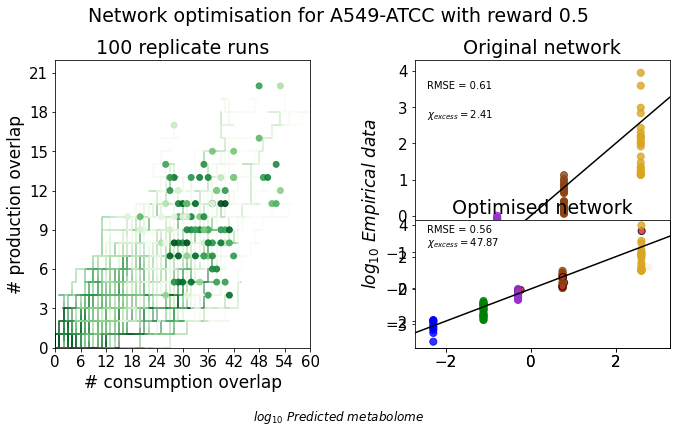

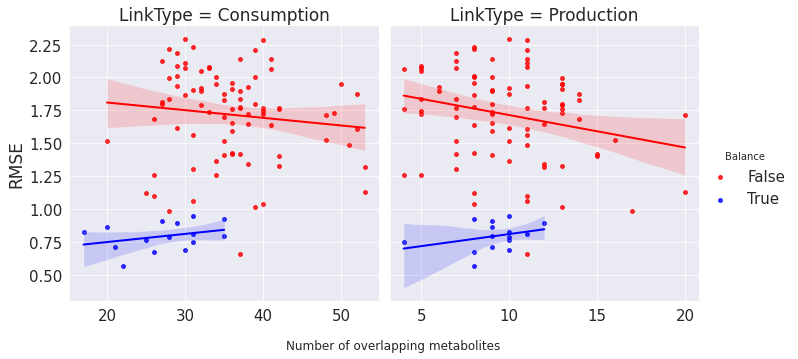

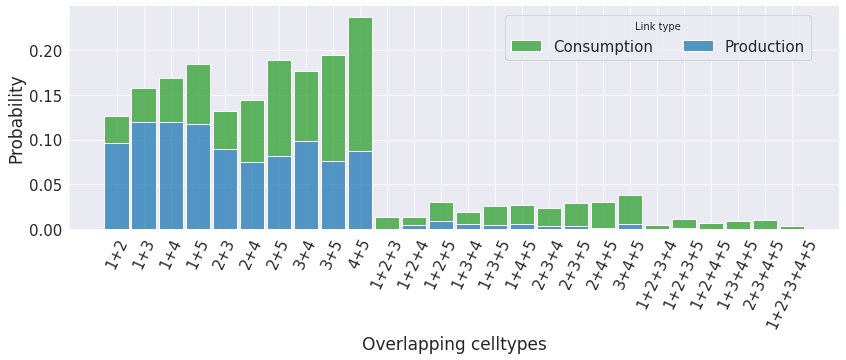

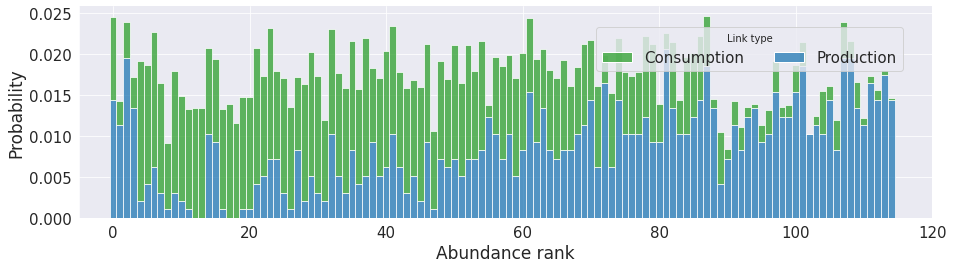

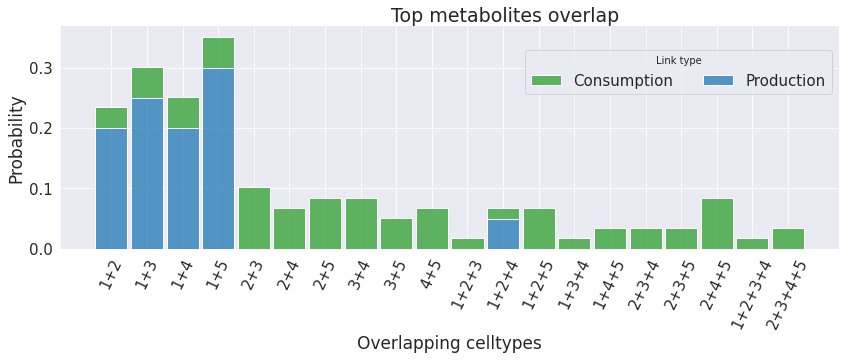

In [ ]:
##### Figure 4
for k in np.arange(0, 1):
        for n_ct in np.arange(5, 6):
            figsave_flag = 0
            reward = 0.5
            penalty = 0.5
            cl = sublinear_cell_lines[k]
            pickle_path = '../raw-output/'+str(n_ct)+'-celltypes/optim-net/'+cl

            [x_ori_list, x_optim_list, error_plot_list, log_bias_list, log_bias_combined_list, n_pred_list, residual_list, balance_flag_list, prod_overlap_list, con_overlap_list,
                        metabolome_pred_before_list, metabolome_meas_before_list,
                        metabolome_pred_after_list, metabolome_meas_after_list,
                        valid_index_before_list, valid_index_after_list] = pd.read_pickle(pickle_path + '/reward-'+str(reward)+'-penalty-'+str(penalty)+'-optimised_network_output.pickle')
            max_links = int(len(x_ori_list[0].flatten())/2)
            n_reps = len(balance_flag_list)

            init_pred_error = np.array([arr[0] for arr in log_bias_list])
            final_pred_error = np.array([arr[-1] for arr in log_bias_list])

            init_residual = np.array([arr[0] for arr in residual_list])
            final_residual = np.array([arr[-1] for arr in residual_list])

            i_best_net = np.where(final_pred_error == final_pred_error.min())[0] #np.where(pred_error_change == pred_error_change.max())[0]
            x_ori_best = x_ori_list[i_best_net].flatten()
            x_optim_best = x_optim_list[i_best_net].flatten()

            fig = plt.figure(figsize=(9.5, 6))
            gs = GridSpec(2, 2, figure=fig)
            ax1 = fig.add_subplot(gs[:, 0])
            ax2 = fig.add_subplot(gs[:, 1])
            ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)

            #### A quick glance of where sims have begun and ended
            # colors = np.where(balance_flag_list, 'b', 'tab:red')
            for i in range(n_reps):
                # sns.lineplot(log_bias_list[i], ax=ax1, color=colors[i])
                log_bias = np.array(log_bias_list[i])
                norm_log_bias = log_bias/log_bias.sum()
                lines = colored_line(con_overlap_list[i], prod_overlap_list[i],
                                    c=norm_log_bias, ax=ax1, cmap='Greens', alpha=0.6, zorder=1)

            con_overlap_final = np.array([arr[-1] for arr in con_overlap_list])
            prod_overlap_final = np.array([arr[-1] for arr in prod_overlap_list])
            final_error = np.array([arr[-1] for arr in log_bias_list])
            ax1.scatter(x=con_overlap_final, y=prod_overlap_final,
                        s=35, c=final_error, cmap='Greens', alpha=0.9, zorder=2)
            ax1.set_xlabel("# consumption overlap")
            ax1.set_ylabel("# production overlap")
            ax1.set_title("%d replicate runs" % n_reps)
            ax1.set_xlim(0, 60)
            ax1.set_ylim(0, 22)
            ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

            ##### Check out the best performing network
            # pred_error_change = np.array([list[0]-list[-1] for list in log_bias_list])

            p_arr_ori = np.array([i*j for i, j in zip(x_ori_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)
            p_arr_optim = np.array([i*j for i, j in zip(x_optim_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)

            met_pred_before = metabolome_pred_before_list[i_best_net][0].astype(np.float64)
            met_pred_after = metabolome_pred_after_list[i_best_net][0].astype(np.float64)

            met_meas_before = metabolome_meas_before_list[i_best_net][0].astype(np.float64)
            met_meas_after = metabolome_meas_after_list[i_best_net][0].astype(np.float64)

            i_before = valid_index_before_list[i_best_net][0].astype(bool)
            i_after = valid_index_after_list[i_best_net][0].astype(bool)

            c_before = np.where(p_arr_ori == 0, 'tab:gray', np.where(p_arr_ori == 1, 'b', 
                                np.where(p_arr_ori == 2, 'g',
                                        np.where(p_arr_ori == 3, 'darkorchid', 
                                                np.where(p_arr_ori == 4, 'saddlebrown', 
                                                        np.where(p_arr_ori == 5, 'goldenrod',
                                                                 np.where(p_arr_ori == 6, 'black', 'tab:pink')))))))                     
            # c_before = np.where(i_before, c_before, 'tab:gray')

            c_after = np.where(p_arr_optim == 0, 'tab:gray', np.where(p_arr_optim == 1, 'b', 
                                np.where(p_arr_optim == 2, 'g',
                                        np.where(p_arr_optim == 3, 'darkorchid', 
                                                np.where(p_arr_optim == 4, 'saddlebrown', 
                                                        np.where(p_arr_optim == 5, 'goldenrod',
                                                                 np.where(p_arr_optim == 6, 'black', 'tab:pink')))))))
            # c_after = np.where(i_after, c_after, 'tab:gray')

            ori_list = x_ori_best[max_links:].reshape(n_ct, -1)
            overlap_colours_before = np.array([np.where(ori_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
            c_before[overlap_colours_before == 'overlap'] = 'tab:red'


            optim_list = x_optim_best[max_links:].reshape(n_ct, -1)
            overlap_colours_after = np.array([np.where(optim_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
            c_after[overlap_colours_after == 'overlap'] = 'tab:red'

            a_before = np.where(i_before, 0.8, 0.1)
            a_after = np.where(i_after, 0.8, 0.1)

            edgecolor_before = np.where(overlap_colours_before == 'overlap', 'k', c_before)
            edgecolor_after = np.where(overlap_colours_after == 'overlap', 'k', c_after)

            # fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 7))
            ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
            # ax2.scatter(np.log10(metabolome_pred_old+1e-7), np.log10(metabolome_measured_old+1e-7), c='k', s=9)
            ax2.axline((-2, -2), (3, 3), c='k')
            ax2.set_title('Original network')
            ax2.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{init_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)
            # ax2.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
            ax2.set_ylabel(r'$log_{10}\ Empirical\ data$')
            ax2.text(0.05, 0.9, f'RMSE = {init_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)

            ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)
            # ax3.scatter(np.log10(metabolome_pred+1e-7), np.log10(metabolome_measured+1e-7), c='k', s=9)
            ax3.axline((-2, -2), (2, 2), c='k')
            ax3.set_title('Optimised network')
            ax3.text(0.05, 0.9, f'RMSE = {final_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
            ax3.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{final_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
            # ax3.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
            # ax3.set_ylabel(r'$log_{10}\ Empirical\ data$')
            # ax3.set_xlabel('', labelpad=0.1)
            fig.supxlabel(r'$log_{10}\ Predicted\ metabolome$')
            fig.tight_layout(pad=0.2)


            fig.suptitle(f'Network optimisation for {cl} with reward {reward}')
            fig.tight_layout()


            fig_path = '../figures/'+str(n_ct)+'-celltypes/optim-net/'+cl
            if figsave_flag:
                try:
                    os.makedirs(fig_path)
                except:
                    pass
                fig.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-network-predictions.png', dpi=300)
                plt.close(fig)

            #### More overlap means less error?
            num_prod_overlap = []
            num_con_overlap = []
            for x in x_optim_list:
                ## Production overlap
                optim_list = x[max_links:].reshape(n_ct, -1)
                prod_overlap = np.array([optim_list[:, i].sum() for i in range(115)])
                num_prod_overlap.append(len(prod_overlap[prod_overlap > 1]))
                
                ## Consumption overlap
                optim_list = x[:max_links].reshape(n_ct, -1)
                con_overlap = np.array([optim_list[:, i].sum() for i in range(115)])
                num_con_overlap.append(len(con_overlap[con_overlap > 1]))
            num_con_overlap, num_prod_overlap = np.array(num_con_overlap), np.array(num_prod_overlap)
            
            overlap_df = pd.DataFrame({'LinkType': np.concatenate([np.repeat('Consumption', len(num_con_overlap)), np.repeat('Production', len(num_prod_overlap))]),
                                       'Balance': np.concatenate([balance_flag_list, balance_flag_list]),
                                       'Overlap': np.concatenate([num_con_overlap, num_prod_overlap]),
                                       'RMSE': np.concatenate([final_error, final_error])})
            with sns.axes_style('darkgrid'):
                f = sns.lmplot(data=overlap_df, x='Overlap', y='RMSE', col='LinkType',
                           hue='Balance', palette={False: 'r', True: 'b'},
                           line_kws={'linewidth': 2}, scatter_kws={'s': 15},
                           facet_kws=dict(sharex=False))
                f.set_xlabels('')
                f.figure.supxlabel('Number of overlapping metabolites')
                # f.figure.tight_layout()

            if figsave_flag:
                f.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlap-vs-rmse-lmplot.png', dpi=300)
                plt.close(f.figure)
            else:
                plt.show()            


            ###### Which overlaps are learnt, which metabolites have overlap either in production or consumption across replicates for each cell line
            consumption_overlap_indices, consumption_overlap_mets, production_overlap_indices, production_overlap_mets = [[]], [[]], [[]], [[]]
            
            max_links = len(x_optim_best)//2
            met_ID = diet.index.to_numpy()
            for x in x_optim_list:
                clist, cmets, plist, pmets = calculate_overlap_stats(x, n_ct, max_links, met_ID)
                consumption_overlap_indices.append(clist)
                consumption_overlap_mets.append(cmets)
                production_overlap_indices.append(plist)
                production_overlap_mets.append(pmets)

            consumption_overlap_indices = np.concatenate(consumption_overlap_indices)
            consumption_overlap_mets = np.concatenate(consumption_overlap_mets).astype(int)
            production_overlap_indices = np.concatenate(production_overlap_indices)
            production_overlap_mets = np.concatenate(production_overlap_mets).astype(int)

            ### Overlapping links
            overlap_indices_df = pd.DataFrame({'LinkType': np.concatenate([['Consumption']*len(consumption_overlap_indices), ['Production']*len(production_overlap_indices)]),
                                            'Overlap': np.concatenate([consumption_overlap_indices, production_overlap_indices])})
            
            unique_indices = np.unique(overlap_indices_df['Overlap'].values) # All unique overlaps
            index_len = np.array([len(i) for i in unique_indices]) # How many celltypes in each overlap
            unique_indices_sorted = [[]]
            for i in range(3, n_ct + n_ct - 1 + 1): # Range limits based on the string length for n_ct celltype overlap e.g., '1+2' is a string of length 3, '1+2+3' is of length 5, so this goes as n + (n-1), where n is the number of overlapping celltypes. The extra plus one is to account for the range function not including the last number
                if len(unique_indices[index_len == i]) > 0: # If there is an overlap of this length
                    unique_indices_sorted.append(unique_indices[index_len == i]) # Retrieving all overlaps of a given length this way sorts the unique elements of that particular length
            unique_indices_sorted = np.concatenate(unique_indices_sorted[1:])

            overlap_indices_df['Overlap'] = pd.Categorical(overlap_indices_df['Overlap'], categories=unique_indices_sorted) # This sets the column to categorical with the levels in the order above, giving 2-celltype overlaps first, then three and so on, and sorted by celltype number within each overlap length
            with sns.axes_style('darkgrid'):
                g = sns.displot(data=overlap_indices_df, x='Overlap',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False, 
                                discrete=True, shrink=0.9, height=4, aspect=3)
                g.set_xticklabels(rotation=65)
                g.set_xlabels('Overlapping celltypes')
                sns.move_legend(g, "lower center", bbox_to_anchor=(0.65, 0.75), ncol=2,
                                title='Link type', frameon=True)
                
            if figsave_flag:
                g.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlapping-links.png', dpi=300)
                plt.close(g.figure)
            else:
                plt.show()

            ### Overlapping mets
            overlap_mets_df = pd.DataFrame({'LinkType': np.concatenate([['Consumption']*len(consumption_overlap_mets), ['Production']*len(production_overlap_mets)]),
                                            'Metabolite': np.concatenate([consumption_overlap_mets, production_overlap_mets])})
            mets_order = np.array(diet.sort_values(inplace=False).index) # IDs of overlapping metabolites sorted by their abundances in the fresh medium
            mets_ranks = np.arange(len(mets_order)) # Assigning ranks to the sorted metabolites
            overlap_mets_df.loc[:, 'MetRanks'] = np.array([mets_ranks[np.where(i == mets_order)[0]][0] for i in overlap_mets_df['Metabolite'].values]) # Mapping metabolite IDs in the dataframe to ranks based on fresh medium abundaces
            with sns.axes_style('darkgrid'): # Histogram of ranks
                h = sns.displot(data=overlap_mets_df, x='MetRanks',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False,
                                discrete=True, height=3.85, aspect=3.5, legend=True)
                h.set_xlabels('Abundance rank')
                sns.move_legend(h, "lower center", bbox_to_anchor=(0.67, 0.7), ncol=2,
                                title='Link type', frameon=True)
                plt.xlim(-5, 120)
            if figsave_flag:
                h.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlapping-metabolites.png', dpi=300)
                plt.close(h.figure)
            else:
                plt.show()

            ### Which overlapping links are common among the metabolites with the highest learnt overlap
            ### Consumption
            top_met_consumption = overlap_mets_df[overlap_mets_df['LinkType'] == 'Consumption']['Metabolite'].value_counts().reset_index().iloc[0, 0]
            top_met_consumption_links = overlap_indices_df[(overlap_indices_df['LinkType']=='Consumption')*(overlap_mets_df['Metabolite']==top_met_consumption)]

            ### Production
            top_met_production = overlap_mets_df[overlap_mets_df['LinkType'] == 'Production']['Metabolite'].value_counts().reset_index().iloc[0, 0]
            top_met_production_links = overlap_indices_df[(overlap_indices_df['LinkType']=='Production')*(overlap_mets_df['Metabolite']==top_met_production)]

            top_met_links_df = pd.concat([top_met_consumption_links, top_met_production_links])
            top_met_unique_indices = np.unique(top_met_links_df['Overlap'].values) # All unique overlaps
            index_len = np.array([len(i) for i in top_met_unique_indices]) # How many celltypes in each overlap
            unique_indices_sorted = [[]]
            for i in range(3, n_ct + n_ct - 1): # Range limits based on the string length for n_ct celltype overlap e.g., '1+2' is a string of length 3, '1+2+3' is of length 5, so this goes as n + (n-1), where n is the number of overlapping celltypes
                if len(top_met_unique_indices[index_len == i]) > 0: # If there is an overlap of this length
                    unique_indices_sorted.append(top_met_unique_indices[index_len == i]) # Retrieving all overlaps of a given length this way sorts the unique elements of that particular length
            unique_indices_sorted = np.concatenate(unique_indices_sorted[1:])
            top_met_links_df['Overlap'] = pd.Categorical(top_met_links_df['Overlap'], categories=unique_indices_sorted)
            with sns.axes_style('darkgrid'):
                q = sns.displot(data=top_met_links_df, x='Overlap',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False, 
                                discrete=True, shrink=0.9, height=4, aspect=3)
                q.set_xticklabels(rotation=65)
                q.set_xlabels('Overlapping celltypes')
                q.figure.suptitle('Top metabolites overlap', y=1.03)
                sns.move_legend(q, "lower center", bbox_to_anchor=(0.67, 0.7), ncol=2,
                                title='Link type', frameon=True)
            if figsave_flag:
                q.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-top-mets-overlapping-links.png', dpi=300)
                plt.close(q.figure)
            else:
                plt.show()

<ipython-input-3-6e431941928c>:103: RuntimeWarning: divide by zero encountered in log10
  ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
<ipython-input-3-6e431941928c>:112: RuntimeWarning: divide by zero encountered in log10
  ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)


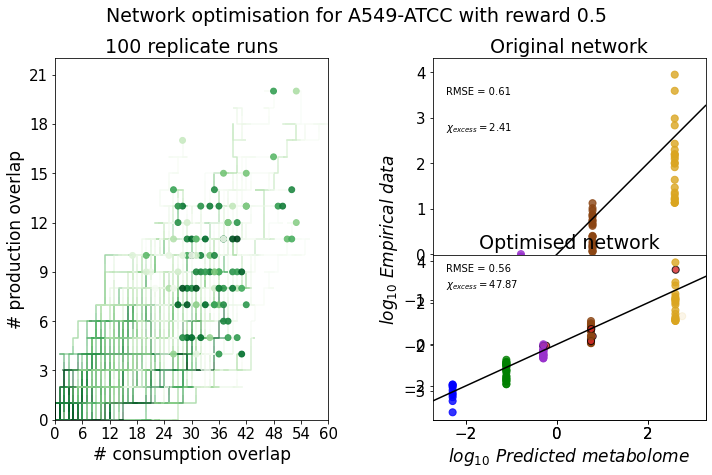

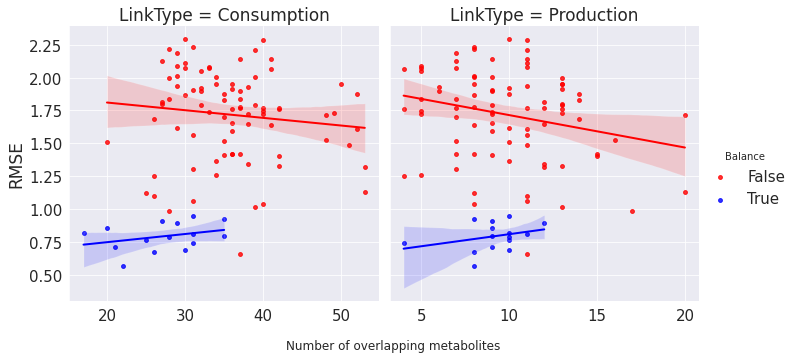

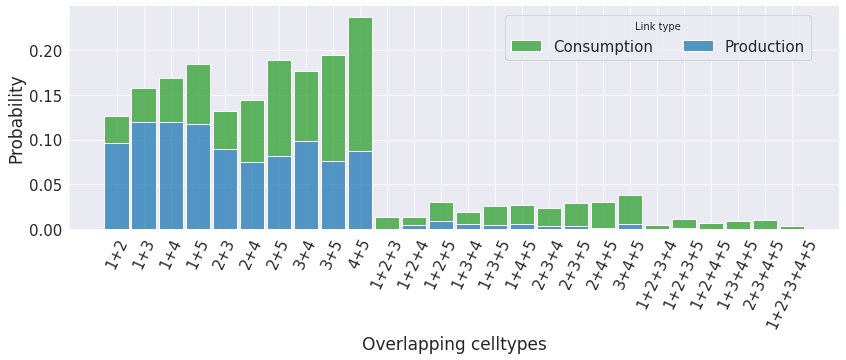

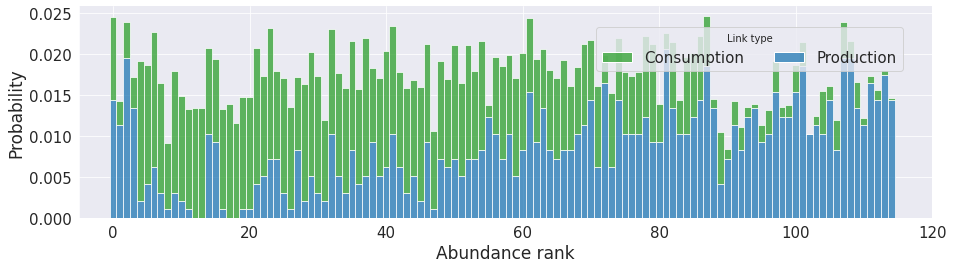

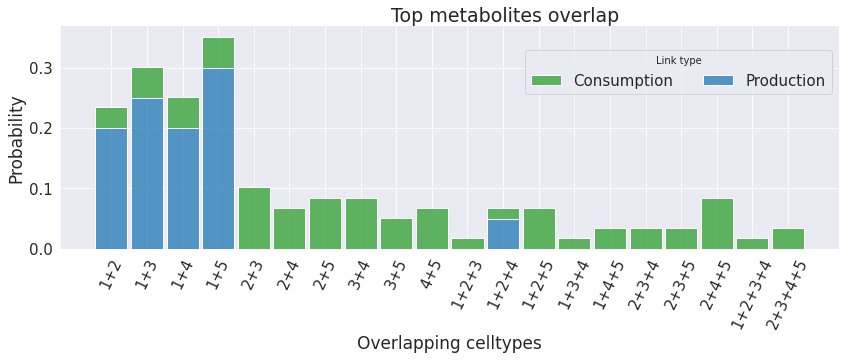

In [ ]:
##### Figure 4
for k in np.arange(0, 1):
        for n_ct in np.arange(5, 6):
            figsave_flag = 0
            reward = 0.5
            penalty = 0.5
            cl = sublinear_cell_lines[k]
            pickle_path = '../raw-output/'+str(n_ct)+'-celltypes/optim-net/'+cl

            [x_ori_list, x_optim_list, error_plot_list, log_bias_list, log_bias_combined_list, n_pred_list, residual_list, balance_flag_list, prod_overlap_list, con_overlap_list,
                        metabolome_pred_before_list, metabolome_meas_before_list,
                        metabolome_pred_after_list, metabolome_meas_after_list,
                        valid_index_before_list, valid_index_after_list] = pd.read_pickle(pickle_path + '/reward-'+str(reward)+'-penalty-'+str(penalty)+'-optimised_network_output.pickle')
            max_links = int(len(x_ori_list[0].flatten())/2)
            n_reps = len(balance_flag_list)

            init_pred_error = np.array([arr[0] for arr in log_bias_list])
            final_pred_error = np.array([arr[-1] for arr in log_bias_list])

            init_residual = np.array([arr[0] for arr in residual_list])
            final_residual = np.array([arr[-1] for arr in residual_list])

            i_best_net = np.where(final_pred_error == final_pred_error.min())[0] #np.where(pred_error_change == pred_error_change.max())[0]
            x_ori_best = x_ori_list[i_best_net].flatten()
            x_optim_best = x_optim_list[i_best_net].flatten()

            fig = plt.figure(figsize=(10, 7))
            gs = GridSpec(2, 2, figure=fig)
            ax1 = fig.add_subplot(gs[:, 0])
            ax2 = fig.add_subplot(gs[:, 1])
            ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)

            #### A quick glance of where sims have begun and ended
            # colors = np.where(balance_flag_list, 'b', 'tab:red')
            for i in range(n_reps):
                # sns.lineplot(log_bias_list[i], ax=ax1, color=colors[i])
                log_bias = np.array(log_bias_list[i])
                norm_log_bias = log_bias/log_bias.sum()
                lines = colored_line(con_overlap_list[i], prod_overlap_list[i],
                                    c=norm_log_bias, ax=ax1, cmap='Greens', alpha=0.6, zorder=1)

            con_overlap_final = np.array([arr[-1] for arr in con_overlap_list])
            prod_overlap_final = np.array([arr[-1] for arr in prod_overlap_list])
            final_error = np.array([arr[-1] for arr in log_bias_list])
            ax1.scatter(x=con_overlap_final, y=prod_overlap_final,
                        s=35, c=final_error, cmap='Greens', alpha=0.9, zorder=2)
            ax1.set_xlabel("# consumption overlap")
            ax1.set_ylabel("# production overlap")
            ax1.set_title("%d replicate runs" % n_reps)
            ax1.set_xlim(0, 60)
            ax1.set_ylim(0, 22)
            ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

            ##### Check out the best performing network
            # pred_error_change = np.array([list[0]-list[-1] for list in log_bias_list])

            p_arr_ori = np.array([i*j for i, j in zip(x_ori_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)
            p_arr_optim = np.array([i*j for i, j in zip(x_optim_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)

            met_pred_before = metabolome_pred_before_list[i_best_net][0].astype(np.float64)
            met_pred_after = metabolome_pred_after_list[i_best_net][0].astype(np.float64)

            met_meas_before = metabolome_meas_before_list[i_best_net][0].astype(np.float64)
            met_meas_after = metabolome_meas_after_list[i_best_net][0].astype(np.float64)

            i_before = valid_index_before_list[i_best_net][0].astype(bool)
            i_after = valid_index_after_list[i_best_net][0].astype(bool)

            c_before = np.where(p_arr_ori == 0, 'tab:gray', np.where(p_arr_ori == 1, 'b', 
                                np.where(p_arr_ori == 2, 'g',
                                        np.where(p_arr_ori == 3, 'darkorchid', 
                                                np.where(p_arr_ori == 4, 'saddlebrown', 
                                                        np.where(p_arr_ori == 5, 'goldenrod',
                                                                 np.where(p_arr_ori == 6, 'black', 'tab:pink')))))))                     
            # c_before = np.where(i_before, c_before, 'tab:gray')

            c_after = np.where(p_arr_optim == 0, 'tab:gray', np.where(p_arr_optim == 1, 'b', 
                                np.where(p_arr_optim == 2, 'g',
                                        np.where(p_arr_optim == 3, 'darkorchid', 
                                                np.where(p_arr_optim == 4, 'saddlebrown', 
                                                        np.where(p_arr_optim == 5, 'goldenrod',
                                                                 np.where(p_arr_optim == 6, 'black', 'tab:pink')))))))
            # c_after = np.where(i_after, c_after, 'tab:gray')

            ori_list = x_ori_best[max_links:].reshape(n_ct, -1)
            overlap_colours_before = np.array([np.where(ori_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
            c_before[overlap_colours_before == 'overlap'] = 'tab:red'


            optim_list = x_optim_best[max_links:].reshape(n_ct, -1)
            overlap_colours_after = np.array([np.where(optim_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
            c_after[overlap_colours_after == 'overlap'] = 'tab:red'

            a_before = np.where(i_before, 0.8, 0.1)
            a_after = np.where(i_after, 0.8, 0.1)

            edgecolor_before = np.where(overlap_colours_before == 'overlap', 'k', c_before)
            edgecolor_after = np.where(overlap_colours_after == 'overlap', 'k', c_after)

            # fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 7))
            ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
            # ax2.scatter(np.log10(metabolome_pred_old+1e-7), np.log10(metabolome_measured_old+1e-7), c='k', s=9)
            ax2.axline((-2, -2), (3, 3), c='k')
            ax2.set_title('Original network')
            ax2.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{init_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)
            # ax2.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
            ax2.set_ylabel(r'$log_{10}\ Empirical\ data$')
            ax2.text(0.05, 0.9, f'RMSE = {init_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)

            ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)
            # ax3.scatter(np.log10(metabolome_pred+1e-7), np.log10(metabolome_measured+1e-7), c='k', s=9)
            ax3.axline((-2, -2), (2, 2), c='k')
            ax3.set_title('Optimised network')
            ax3.text(0.05, 0.9, f'RMSE = {final_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
            ax3.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{final_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
            ax3.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
            # ax3.set_ylabel(r'$log_{10}\ Empirical\ data$')
            fig.tight_layout(pad=0.2)


            fig.suptitle(f'Network optimisation for {cl} with reward {reward}')
            fig.tight_layout()


            fig_path = '../figures/'+str(n_ct)+'-celltypes/optim-net/'+cl
            if figsave_flag:
                try:
                    os.makedirs(fig_path)
                except:
                    pass
                fig.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-network-predictions.png', dpi=300)
                plt.close(fig)

            #### More overlap means less error?
            num_prod_overlap = []
            num_con_overlap = []
            for x in x_optim_list:
                ## Production overlap
                optim_list = x[max_links:].reshape(n_ct, -1)
                prod_overlap = np.array([optim_list[:, i].sum() for i in range(115)])
                num_prod_overlap.append(len(prod_overlap[prod_overlap > 1]))
                
                ## Consumption overlap
                optim_list = x[:max_links].reshape(n_ct, -1)
                con_overlap = np.array([optim_list[:, i].sum() for i in range(115)])
                num_con_overlap.append(len(con_overlap[con_overlap > 1]))
            num_con_overlap, num_prod_overlap = np.array(num_con_overlap), np.array(num_prod_overlap)
            
            overlap_df = pd.DataFrame({'LinkType': np.concatenate([np.repeat('Consumption', len(num_con_overlap)), np.repeat('Production', len(num_prod_overlap))]),
                                       'Balance': np.concatenate([balance_flag_list, balance_flag_list]),
                                       'Overlap': np.concatenate([num_con_overlap, num_prod_overlap]),
                                       'RMSE': np.concatenate([final_error, final_error])})
            with sns.axes_style('darkgrid'):
                f = sns.lmplot(data=overlap_df, x='Overlap', y='RMSE', col='LinkType',
                           hue='Balance', palette={False: 'r', True: 'b'},
                           line_kws={'linewidth': 2}, scatter_kws={'s': 15},
                           facet_kws=dict(sharex=False))
                f.set_xlabels('')
                f.figure.supxlabel('Number of overlapping metabolites')
                # f.figure.tight_layout()

            if figsave_flag:
                f.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlap-vs-rmse-lmplot.png', dpi=300)
                plt.close(f.figure)
            else:
                plt.show()            


            ###### Which overlaps are learnt, which metabolites have overlap either in production or consumption across replicates for each cell line
            consumption_overlap_indices, consumption_overlap_mets, production_overlap_indices, production_overlap_mets = [[]], [[]], [[]], [[]]
            
            max_links = len(x_optim_best)//2
            met_ID = diet.index.to_numpy()
            for x in x_optim_list:
                clist, cmets, plist, pmets = calculate_overlap_stats(x, n_ct, max_links, met_ID)
                consumption_overlap_indices.append(clist)
                consumption_overlap_mets.append(cmets)
                production_overlap_indices.append(plist)
                production_overlap_mets.append(pmets)

            consumption_overlap_indices = np.concatenate(consumption_overlap_indices)
            consumption_overlap_mets = np.concatenate(consumption_overlap_mets).astype(int)
            production_overlap_indices = np.concatenate(production_overlap_indices)
            production_overlap_mets = np.concatenate(production_overlap_mets).astype(int)

            ### Overlapping links
            overlap_indices_df = pd.DataFrame({'LinkType': np.concatenate([['Consumption']*len(consumption_overlap_indices), ['Production']*len(production_overlap_indices)]),
                                            'Overlap': np.concatenate([consumption_overlap_indices, production_overlap_indices])})
            
            unique_indices = np.unique(overlap_indices_df['Overlap'].values) # All unique overlaps
            index_len = np.array([len(i) for i in unique_indices]) # How many celltypes in each overlap
            unique_indices_sorted = [[]]
            for i in range(3, n_ct + n_ct - 1 + 1): # Range limits based on the string length for n_ct celltype overlap e.g., '1+2' is a string of length 3, '1+2+3' is of length 5, so this goes as n + (n-1), where n is the number of overlapping celltypes. The extra plus one is to account for the range function not including the last number
                if len(unique_indices[index_len == i]) > 0: # If there is an overlap of this length
                    unique_indices_sorted.append(unique_indices[index_len == i]) # Retrieving all overlaps of a given length this way sorts the unique elements of that particular length
            unique_indices_sorted = np.concatenate(unique_indices_sorted[1:])

            overlap_indices_df['Overlap'] = pd.Categorical(overlap_indices_df['Overlap'], categories=unique_indices_sorted) # This sets the column to categorical with the levels in the order above, giving 2-celltype overlaps first, then three and so on, and sorted by celltype number within each overlap length
            with sns.axes_style('darkgrid'):
                g = sns.displot(data=overlap_indices_df, x='Overlap',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False, 
                                discrete=True, shrink=0.9, height=4, aspect=3)
                g.set_xticklabels(rotation=65)
                g.set_xlabels('Overlapping celltypes')
                sns.move_legend(g, "lower center", bbox_to_anchor=(0.65, 0.75), ncol=2,
                                title='Link type', frameon=True)
                
            if figsave_flag:
                g.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlapping-links.png', dpi=300)
                plt.close(g.figure)
            else:
                plt.show()

            ### Overlapping mets
            overlap_mets_df = pd.DataFrame({'LinkType': np.concatenate([['Consumption']*len(consumption_overlap_mets), ['Production']*len(production_overlap_mets)]),
                                            'Metabolite': np.concatenate([consumption_overlap_mets, production_overlap_mets])})
            mets_order = np.array(diet.sort_values(inplace=False).index) # IDs of overlapping metabolites sorted by their abundances in the fresh medium
            mets_ranks = np.arange(len(mets_order)) # Assigning ranks to the sorted metabolites
            overlap_mets_df.loc[:, 'MetRanks'] = np.array([mets_ranks[np.where(i == mets_order)[0]][0] for i in overlap_mets_df['Metabolite'].values]) # Mapping metabolite IDs in the dataframe to ranks based on fresh medium abundaces
            with sns.axes_style('darkgrid'): # Histogram of ranks
                h = sns.displot(data=overlap_mets_df, x='MetRanks',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False,
                                discrete=True, height=3.85, aspect=3.5, legend=True)
                h.set_xlabels('Abundance rank')
                sns.move_legend(h, "lower center", bbox_to_anchor=(0.67, 0.7), ncol=2,
                                title='Link type', frameon=True)
                plt.xlim(-5, 120)
            if figsave_flag:
                h.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-overlapping-metabolites.png', dpi=300)
                plt.close(h.figure)
            else:
                plt.show()

            ### Which overlapping links are common among the metabolites with the highest learnt overlap
            ### Consumption
            top_met_consumption = overlap_mets_df[overlap_mets_df['LinkType'] == 'Consumption']['Metabolite'].value_counts().reset_index().iloc[0, 0]
            top_met_consumption_links = overlap_indices_df[(overlap_indices_df['LinkType']=='Consumption')*(overlap_mets_df['Metabolite']==top_met_consumption)]

            ### Production
            top_met_production = overlap_mets_df[overlap_mets_df['LinkType'] == 'Production']['Metabolite'].value_counts().reset_index().iloc[0, 0]
            top_met_production_links = overlap_indices_df[(overlap_indices_df['LinkType']=='Production')*(overlap_mets_df['Metabolite']==top_met_production)]

            top_met_links_df = pd.concat([top_met_consumption_links, top_met_production_links])
            top_met_unique_indices = np.unique(top_met_links_df['Overlap'].values) # All unique overlaps
            index_len = np.array([len(i) for i in top_met_unique_indices]) # How many celltypes in each overlap
            unique_indices_sorted = [[]]
            for i in range(3, n_ct + n_ct - 1): # Range limits based on the string length for n_ct celltype overlap e.g., '1+2' is a string of length 3, '1+2+3' is of length 5, so this goes as n + (n-1), where n is the number of overlapping celltypes
                if len(top_met_unique_indices[index_len == i]) > 0: # If there is an overlap of this length
                    unique_indices_sorted.append(top_met_unique_indices[index_len == i]) # Retrieving all overlaps of a given length this way sorts the unique elements of that particular length
            unique_indices_sorted = np.concatenate(unique_indices_sorted[1:])
            top_met_links_df['Overlap'] = pd.Categorical(top_met_links_df['Overlap'], categories=unique_indices_sorted)
            with sns.axes_style('darkgrid'):
                q = sns.displot(data=top_met_links_df, x='Overlap',
                                hue='LinkType', palette={'Consumption': 'tab:green',
                                                        'Production': 'tab:blue'},
                                multiple='stack', stat='probability', common_norm=False, 
                                discrete=True, shrink=0.9, height=4, aspect=3)
                q.set_xticklabels(rotation=65)
                q.set_xlabels('Overlapping celltypes')
                q.figure.suptitle('Top metabolites overlap', y=1.03)
                sns.move_legend(q, "lower center", bbox_to_anchor=(0.67, 0.7), ncol=2,
                                title='Link type', frameon=True)
            if figsave_flag:
                q.savefig(fig_path+'/reward-'+str(reward)+'-penalty-'+str(penalty)+'-top-mets-overlapping-links.png', dpi=300)
                plt.close(q.figure)
            else:
                plt.show()

<ipython-input-4-818f74130e27>:76: RuntimeWarning: divide by zero encountered in log10
  ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
<ipython-input-4-818f74130e27>:85: RuntimeWarning: divide by zero encountered in log10
  ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)


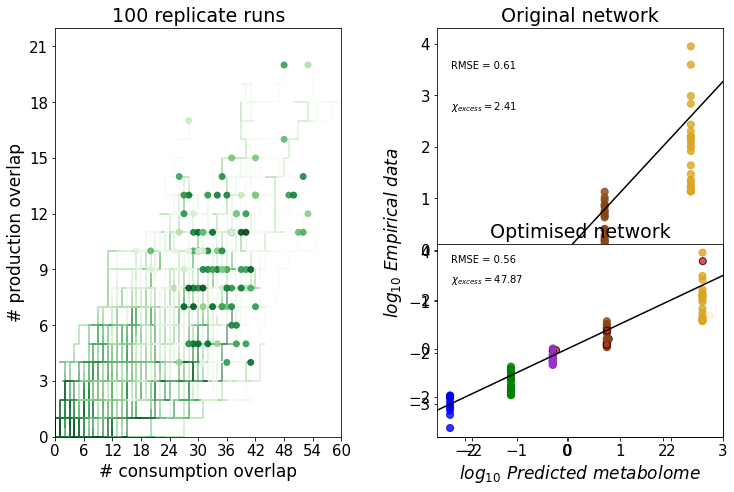

In [ ]:
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[:, 1])
ax3 = fig.add_subplot(gs[1, 1])

#### A quick glance of where sims have begun and ended
# colors = np.where(balance_flag_list, 'b', 'tab:red')
for i in range(n_reps):
    # sns.lineplot(log_bias_list[i], ax=ax1, color=colors[i])
    log_bias = np.array(log_bias_list[i])
    norm_log_bias = log_bias/log_bias.sum()
    lines = colored_line(con_overlap_list[i], prod_overlap_list[i],
                        c=norm_log_bias, ax=ax1, cmap='Greens', alpha=0.6, zorder=1)

con_overlap_final = np.array([arr[-1] for arr in con_overlap_list])
prod_overlap_final = np.array([arr[-1] for arr in prod_overlap_list])
final_error = np.array([arr[-1] for arr in log_bias_list])
ax1.scatter(x=con_overlap_final, y=prod_overlap_final,
            s=35, c=final_error, cmap='Greens', alpha=0.9, zorder=2)
ax1.set_xlabel("# consumption overlap")
ax1.set_ylabel("# production overlap")
ax1.set_title("%d replicate runs" % n_reps)
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 22)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

##### Check out the best performing network
# pred_error_change = np.array([list[0]-list[-1] for list in log_bias_list])

p_arr_ori = np.array([i*j for i, j in zip(x_ori_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)
p_arr_optim = np.array([i*j for i, j in zip(x_optim_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)

met_pred_before = metabolome_pred_before_list[i_best_net][0].astype(np.float64)
met_pred_after = metabolome_pred_after_list[i_best_net][0].astype(np.float64)

met_meas_before = metabolome_meas_before_list[i_best_net][0].astype(np.float64)
met_meas_after = metabolome_meas_after_list[i_best_net][0].astype(np.float64)

i_before = valid_index_before_list[i_best_net][0].astype(bool)
i_after = valid_index_after_list[i_best_net][0].astype(bool)

c_before = np.where(p_arr_ori == 0, 'tab:gray', np.where(p_arr_ori == 1, 'b', 
                    np.where(p_arr_ori == 2, 'g',
                            np.where(p_arr_ori == 3, 'darkorchid', 
                                    np.where(p_arr_ori == 4, 'saddlebrown', 
                                            np.where(p_arr_ori == 5, 'goldenrod',
                                                        np.where(p_arr_ori == 6, 'black', 'tab:pink')))))))                     
# c_before = np.where(i_before, c_before, 'tab:gray')

c_after = np.where(p_arr_optim == 0, 'tab:gray', np.where(p_arr_optim == 1, 'b', 
                    np.where(p_arr_optim == 2, 'g',
                            np.where(p_arr_optim == 3, 'darkorchid', 
                                    np.where(p_arr_optim == 4, 'saddlebrown', 
                                            np.where(p_arr_optim == 5, 'goldenrod',
                                                        np.where(p_arr_optim == 6, 'black', 'tab:pink')))))))
# c_after = np.where(i_after, c_after, 'tab:gray')

ori_list = x_ori_best[max_links:].reshape(n_ct, -1)
overlap_colours_before = np.array([np.where(ori_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_before[overlap_colours_before == 'overlap'] = 'tab:red'


optim_list = x_optim_best[max_links:].reshape(n_ct, -1)
overlap_colours_after = np.array([np.where(optim_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_after[overlap_colours_after == 'overlap'] = 'tab:red'

a_before = np.where(i_before, 0.8, 0.1)
a_after = np.where(i_after, 0.8, 0.1)

edgecolor_before = np.where(overlap_colours_before == 'overlap', 'k', c_before)
edgecolor_after = np.where(overlap_colours_after == 'overlap', 'k', c_after)

# fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 7))
ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
# ax2.scatter(np.log10(metabolome_pred_old+1e-7), np.log10(metabolome_measured_old+1e-7), c='k', s=9)
ax2.axline((-2, -2), (3, 3), c='k')
ax2.set_title('Original network')
ax2.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{init_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)
# ax2.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
ax2.set_ylabel(r'$log_{10}\ Empirical\ data$')
ax2.text(0.05, 0.9, f'RMSE = {init_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)

ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)
# ax3.scatter(np.log10(metabolome_pred+1e-7), np.log10(metabolome_measured+1e-7), c='k', s=9)
ax3.axline((-2, -2), (2, 2), c='k')
ax3.set_title('Optimised network')
ax3.text(0.05, 0.9, f'RMSE = {final_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{final_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
# ax3.set_ylabel(r'$log_{10}\ Empirical\ data$')
fig.tight_layout(pad=0.2)



<ipython-input-5-18e0c3d662a9>:76: RuntimeWarning: divide by zero encountered in log10
  ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
<ipython-input-5-18e0c3d662a9>:85: RuntimeWarning: divide by zero encountered in log10
  ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)


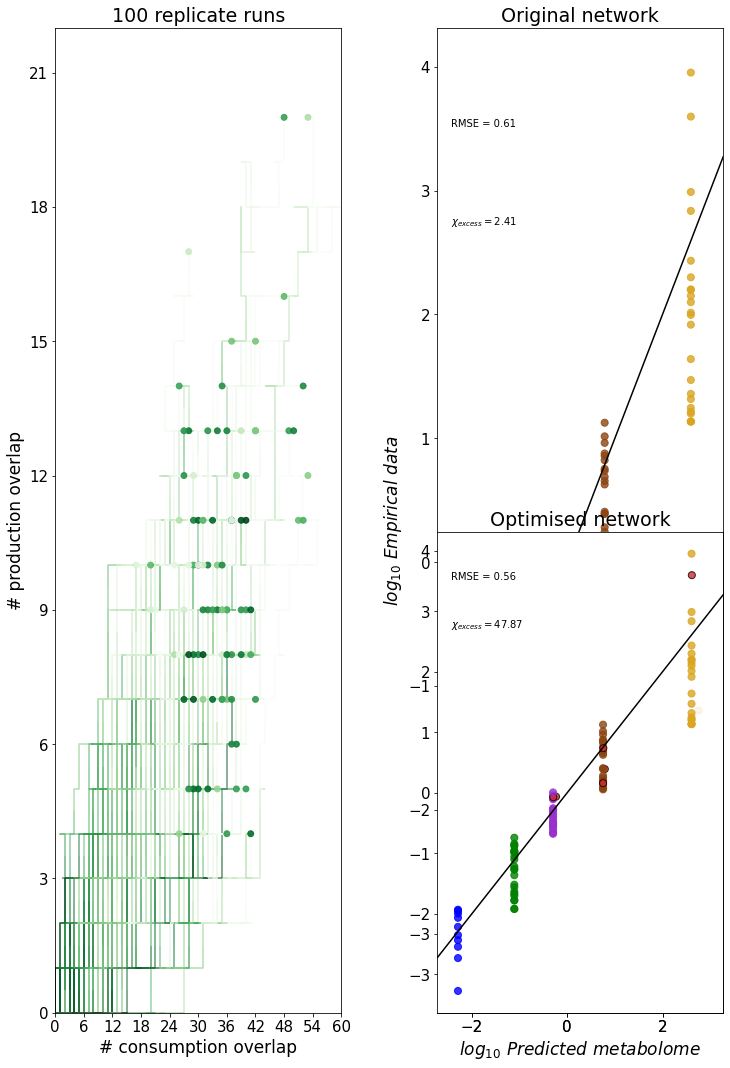

In [ ]:
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[:, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)

#### A quick glance of where sims have begun and ended
# colors = np.where(balance_flag_list, 'b', 'tab:red')
for i in range(n_reps):
    # sns.lineplot(log_bias_list[i], ax=ax1, color=colors[i])
    log_bias = np.array(log_bias_list[i])
    norm_log_bias = log_bias/log_bias.sum()
    lines = colored_line(con_overlap_list[i], prod_overlap_list[i],
                        c=norm_log_bias, ax=ax1, cmap='Greens', alpha=0.6, zorder=1)

con_overlap_final = np.array([arr[-1] for arr in con_overlap_list])
prod_overlap_final = np.array([arr[-1] for arr in prod_overlap_list])
final_error = np.array([arr[-1] for arr in log_bias_list])
ax1.scatter(x=con_overlap_final, y=prod_overlap_final,
            s=35, c=final_error, cmap='Greens', alpha=0.9, zorder=2)
ax1.set_xlabel("# consumption overlap")
ax1.set_ylabel("# production overlap")
ax1.set_title("%d replicate runs" % n_reps)
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 22)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

##### Check out the best performing network
# pred_error_change = np.array([list[0]-list[-1] for list in log_bias_list])

p_arr_ori = np.array([i*j for i, j in zip(x_ori_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)
p_arr_optim = np.array([i*j for i, j in zip(x_optim_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)

met_pred_before = metabolome_pred_before_list[i_best_net][0].astype(np.float64)
met_pred_after = metabolome_pred_after_list[i_best_net][0].astype(np.float64)

met_meas_before = metabolome_meas_before_list[i_best_net][0].astype(np.float64)
met_meas_after = metabolome_meas_after_list[i_best_net][0].astype(np.float64)

i_before = valid_index_before_list[i_best_net][0].astype(bool)
i_after = valid_index_after_list[i_best_net][0].astype(bool)

c_before = np.where(p_arr_ori == 0, 'tab:gray', np.where(p_arr_ori == 1, 'b', 
                    np.where(p_arr_ori == 2, 'g',
                            np.where(p_arr_ori == 3, 'darkorchid', 
                                    np.where(p_arr_ori == 4, 'saddlebrown', 
                                            np.where(p_arr_ori == 5, 'goldenrod',
                                                        np.where(p_arr_ori == 6, 'black', 'tab:pink')))))))                     
# c_before = np.where(i_before, c_before, 'tab:gray')

c_after = np.where(p_arr_optim == 0, 'tab:gray', np.where(p_arr_optim == 1, 'b', 
                    np.where(p_arr_optim == 2, 'g',
                            np.where(p_arr_optim == 3, 'darkorchid', 
                                    np.where(p_arr_optim == 4, 'saddlebrown', 
                                            np.where(p_arr_optim == 5, 'goldenrod',
                                                        np.where(p_arr_optim == 6, 'black', 'tab:pink')))))))
# c_after = np.where(i_after, c_after, 'tab:gray')

ori_list = x_ori_best[max_links:].reshape(n_ct, -1)
overlap_colours_before = np.array([np.where(ori_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_before[overlap_colours_before == 'overlap'] = 'tab:red'


optim_list = x_optim_best[max_links:].reshape(n_ct, -1)
overlap_colours_after = np.array([np.where(optim_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_after[overlap_colours_after == 'overlap'] = 'tab:red'

a_before = np.where(i_before, 0.8, 0.1)
a_after = np.where(i_after, 0.8, 0.1)

edgecolor_before = np.where(overlap_colours_before == 'overlap', 'k', c_before)
edgecolor_after = np.where(overlap_colours_after == 'overlap', 'k', c_after)

# fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 7))
ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
# ax2.scatter(np.log10(metabolome_pred_old+1e-7), np.log10(metabolome_measured_old+1e-7), c='k', s=9)
ax2.axline((-2, -2), (3, 3), c='k')
ax2.set_title('Original network')
ax2.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{init_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)
# ax2.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
ax2.set_ylabel(r'$log_{10}\ Empirical\ data$')
ax2.text(0.05, 0.9, f'RMSE = {init_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)

ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)
# ax3.scatter(np.log10(metabolome_pred+1e-7), np.log10(metabolome_measured+1e-7), c='k', s=9)
ax3.axline((-2, -2), (2, 2), c='k')
ax3.set_title('Optimised network')
ax3.text(0.05, 0.9, f'RMSE = {final_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{final_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
# ax3.set_ylabel(r'$log_{10}\ Empirical\ data$')
fig.tight_layout(pad=0.2)



TypeError: 'other' must be an instance of matplotlib.axes._base._AxesBase, not a bool

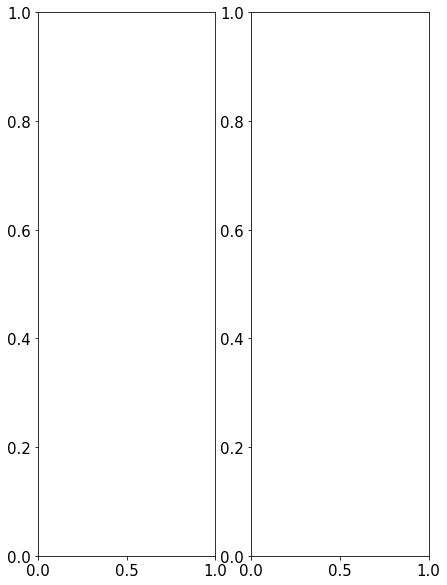

In [ ]:
fig = plt.figure(figsize=(7, 10))
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[:, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2, sharey=False)

#### A quick glance of where sims have begun and ended
# colors = np.where(balance_flag_list, 'b', 'tab:red')
for i in range(n_reps):
    # sns.lineplot(log_bias_list[i], ax=ax1, color=colors[i])
    log_bias = np.array(log_bias_list[i])
    norm_log_bias = log_bias/log_bias.sum()
    lines = colored_line(con_overlap_list[i], prod_overlap_list[i],
                        c=norm_log_bias, ax=ax1, cmap='Greens', alpha=0.6, zorder=1)

con_overlap_final = np.array([arr[-1] for arr in con_overlap_list])
prod_overlap_final = np.array([arr[-1] for arr in prod_overlap_list])
final_error = np.array([arr[-1] for arr in log_bias_list])
ax1.scatter(x=con_overlap_final, y=prod_overlap_final,
            s=35, c=final_error, cmap='Greens', alpha=0.9, zorder=2)
ax1.set_xlabel("# consumption overlap")
ax1.set_ylabel("# production overlap")
ax1.set_title("%d replicate runs" % n_reps)
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 22)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

##### Check out the best performing network
# pred_error_change = np.array([list[0]-list[-1] for list in log_bias_list])

p_arr_ori = np.array([i*j for i, j in zip(x_ori_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)
p_arr_optim = np.array([i*j for i, j in zip(x_optim_best[max_links:].reshape(n_ct, -1), np.arange(1, n_ct+1).tolist())]).sum(0)

met_pred_before = metabolome_pred_before_list[i_best_net][0].astype(np.float64)
met_pred_after = metabolome_pred_after_list[i_best_net][0].astype(np.float64)

met_meas_before = metabolome_meas_before_list[i_best_net][0].astype(np.float64)
met_meas_after = metabolome_meas_after_list[i_best_net][0].astype(np.float64)

i_before = valid_index_before_list[i_best_net][0].astype(bool)
i_after = valid_index_after_list[i_best_net][0].astype(bool)

c_before = np.where(p_arr_ori == 0, 'tab:gray', np.where(p_arr_ori == 1, 'b', 
                    np.where(p_arr_ori == 2, 'g',
                            np.where(p_arr_ori == 3, 'darkorchid', 
                                    np.where(p_arr_ori == 4, 'saddlebrown', 
                                            np.where(p_arr_ori == 5, 'goldenrod',
                                                        np.where(p_arr_ori == 6, 'black', 'tab:pink')))))))                     
# c_before = np.where(i_before, c_before, 'tab:gray')

c_after = np.where(p_arr_optim == 0, 'tab:gray', np.where(p_arr_optim == 1, 'b', 
                    np.where(p_arr_optim == 2, 'g',
                            np.where(p_arr_optim == 3, 'darkorchid', 
                                    np.where(p_arr_optim == 4, 'saddlebrown', 
                                            np.where(p_arr_optim == 5, 'goldenrod',
                                                        np.where(p_arr_optim == 6, 'black', 'tab:pink')))))))
# c_after = np.where(i_after, c_after, 'tab:gray')

ori_list = x_ori_best[max_links:].reshape(n_ct, -1)
overlap_colours_before = np.array([np.where(ori_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_before[overlap_colours_before == 'overlap'] = 'tab:red'


optim_list = x_optim_best[max_links:].reshape(n_ct, -1)
overlap_colours_after = np.array([np.where(optim_list[:, i].sum() > 1, 'overlap', 'no') for i in range(115)])
c_after[overlap_colours_after == 'overlap'] = 'tab:red'

a_before = np.where(i_before, 0.8, 0.1)
a_after = np.where(i_after, 0.8, 0.1)

edgecolor_before = np.where(overlap_colours_before == 'overlap', 'k', c_before)
edgecolor_after = np.where(overlap_colours_after == 'overlap', 'k', c_after)

# fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 7))
ax2.scatter(np.log10(met_pred_before), np.log10(met_meas_before), c=c_before, alpha=a_before, s=50, edgecolors=edgecolor_before)
# ax2.scatter(np.log10(metabolome_pred_old+1e-7), np.log10(metabolome_measured_old+1e-7), c='k', s=9)
ax2.axline((-2, -2), (3, 3), c='k')
ax2.set_title('Original network')
ax2.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{init_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)
# ax2.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
ax2.set_ylabel(r'$log_{10}\ Empirical\ data$')
ax2.text(0.05, 0.9, f'RMSE = {init_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax2.transAxes)

ax3.scatter(np.log10(met_pred_after), np.log10(met_meas_after), c=c_after, alpha=a_after, s=50, edgecolors=edgecolor_after)
# ax3.scatter(np.log10(metabolome_pred+1e-7), np.log10(metabolome_measured+1e-7), c='k', s=9)
ax3.axline((-2, -2), (2, 2), c='k')
ax3.set_title('Optimised network')
ax3.text(0.05, 0.9, f'RMSE = {final_pred_error[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.text(0.05, 0.8, r'$\chi_{excess}=$'+f'{final_residual[i_best_net][0].round(decimals=3):.2f}', transform=ax3.transAxes)
ax3.set_xlabel(r'$log_{10}\ Predicted\ metabolome$')
# ax3.set_ylabel(r'$log_{10}\ Empirical\ data$')
fig.tight_layout(pad=0.2)

